In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, ReduceLROnPlateau
from tensorflow import keras
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Activation, Dropout
from tensorflow.keras.models import Sequential
from src.metrics import metrics
from src.load_data import get_dataset, prepare_df
from src.pipeline import get_preprocessor
from sklearn.model_selection import train_test_split
import tensorflow as tf
import os
seed = 42
tf.keras.utils.set_random_seed(seed)
tf.config.experimental.enable_op_determinism()
os.environ["PYTHONHASHSEED"] = str(seed)

In [2]:
df = get_dataset()

In [3]:
X_train_val, X_test, y_train_val, y_test = prepare_df(df)

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, random_state=42, stratify=y_train_val, shuffle=True, test_size=0.2)

In [5]:
preprocessor = get_preprocessor()

In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(4507, 19)
(4507,)
(1127, 19)
(1127,)
(1409, 19)
(1409,)


In [7]:
early_stop = EarlyStopping(
    monitor="val_f1",
    patience=5,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

In [8]:
reducelr = ReduceLROnPlateau(
    min_lr=1e-7,
    monitor="val_f1",
    factor=0.5,
    patience=3
)

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [10]:
def build_model(hp):
    model = Sequential()
    # Adding Input layer to the model
    model.add(Input(shape=X_train_processed.shape[1:]))

    # Tuning dense layers
    num_dense_layers = hp.Int("num_layers", min_value=2, max_value=7, step=1)
    for i in range(num_dense_layers):
        model.add(
            Dense(
                units=hp.Int(f"neuron_units_{i}", min_value=16, max_value=256, step=32)
            )
        )

        model.add(BatchNormalization())

        model.add(
            Activation(
                hp.Choice(f"activation_{i}", values=["relu", "selu", "elu", "tanh"])
            )
        )

        if hp.Boolean(f"dropout_{i}"):
            model.add(
                Dropout(
                    hp.Float(
                        f"dropout_rate_{i}", min_value=0.1, max_value=0.5, step=0.1
                    )
                )
            )

    model.add(Dense(1, activation="sigmoid"))

    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-4, 1e-5])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.F1Score(average="micro", name="f1"), "accuracy"],
    )

    return model

In [11]:
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_f1", direction="max"),
    max_epochs=10,
    factor=3,
    seed=42,
    directory = "tuner_results",
    project_name = "telco_ann_search"
)

2026-08-20 23:45:59.169909: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-08-20 23:45:59.169937: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-08-20 23:45:59.169942: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-08-20 23:45:59.169963: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-20 23:45:59.169975: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [12]:
tuner.search(
    X_train_processed,
    y_train,
    validation_data=[X_val_processed, y_val],
    callbacks=[early_stop, reducelr]
)

Trial 30 Complete [00h 00m 24s]
val_f1: 0.41935479640960693

Best val_f1 So Far: 0.41935479640960693
Total elapsed time: 00h 10m 46s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp.values)

{'num_layers': 5, 'neuron_units_0': 16, 'activation_0': 'selu', 'dropout_0': False, 'neuron_units_1': 240, 'activation_1': 'selu', 'dropout_1': True, 'learning_rate': 0.01, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0, 'dropout_rate_1': 0.1, 'neuron_units_2': 16, 'activation_2': 'relu', 'dropout_2': False, 'neuron_units_3': 16, 'activation_3': 'relu', 'dropout_3': False, 'neuron_units_4': 16, 'activation_4': 'relu', 'dropout_4': False}


/Users/yugamdeepgoyal/my_gpu/tf_env/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [14]:
final_model = tuner.hypermodel.build(best_hp)

In [15]:
history = final_model.fit(
    X_train_processed,
    y_train,
    epochs=100,
    validation_data=[X_val_processed, y_val],
    callbacks=[early_stop, reducelr],
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.7874 - f1: 0.4194 - loss: 0.4484 - val_accuracy: 0.7808 - val_f1: 0.4194 - val_loss: 0.4479 - learning_rate: 0.0100
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.7959 - f1: 0.4194 - loss: 0.4249 - val_accuracy: 0.8075 - val_f1: 0.4194 - val_loss: 0.4256 - learning_rate: 0.0100
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8005 - f1: 0.4194 - loss: 0.4170 - val_accuracy: 0.8030 - val_f1: 0.4194 - val_loss: 0.4418 - learning_rate: 0.0100
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8010 - f1: 0.4194 - loss: 0.4117 - val_accuracy: 0.8101 - val_f1: 0.4194 - val_loss: 0.4209 - learning_rate: 0.0100
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8036 - f1: 0.4194 - loss: 0.4042 - val_accuracy: 0.7986 - val_f1: 0.4194 - val_loss: 0.4089 - learning_rate: 0.0050
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8085 - f1: 

In [18]:
test_loss, test_f1, test_acc = final_model.evaluate(X_test_processed, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7651 - f1: 0.4195 - loss: 0.4720


In [19]:
test_acc

0.7650816440582275

In [20]:
test_loss

0.4720337390899658

In [21]:
test_f1

0.4195176362991333

In [24]:
y_pred_proba = final_model.predict(X_test_processed)
y_pred = (y_pred_proba >= 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Accuracy score: 0.7650816181689141
recall score: 0.7406417112299465
precision score: 0.5420743639921722
f1 score: 0.6259887005649718
ROC-AUC score: 0.8458394688573717
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.77      1409



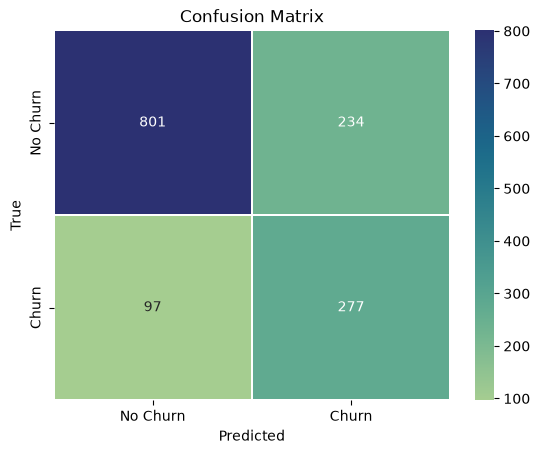

In [25]:
metrics(y_test, y_pred, y_pred_proba)